# Import Qwen

In [1]:
%load_ext autoreload

%autoreload 2

import warnings

# Ignore all FutureWarnings to clean up your notebook outputs
warnings.filterwarnings("ignore", category=FutureWarning)

from langchain_core.messages import HumanMessage, ToolMessage
from IPython.display import Image, display
from app.graph.workflow import build_graph
from app.core.app import container
from pprint import pprint as ppr
from app.memory.extractor import MemoryExtractor

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/nguyen/micromamba/envs/unsloth_fresh/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6450.88it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading model: unsloth/Qwen3-4B-Instruct-2507-bnb-4bit
==((====))==  Unsloth 2026.5.9: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4060 Ti. Num GPUs = 1. Max memory: 7.603 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 398/398 [00:02<00:00, 170.06it/s]


unsloth/Qwen3-4B-Instruct-2507-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


# Test Graph Workflow

Both `max_new_tokens` (=2048) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


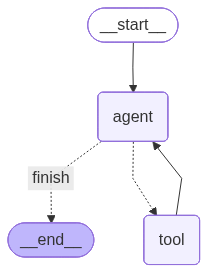

{'messages': [HumanMessage(content='Make your response focus on the why, not what? Why FAISS is popular?', additional_kwargs={}, response_metadata={}, id='e3b45b4a-75da-4c58-b709-21d8bf10bcd8'),
              AIMessage(content='FAISS is popular because it is specifically designed for high-performance, large-scale vector similarity search. Its popularity stems from its efficiency in indexing and searching massive datasets with low latency, making it ideal for real-time applications like recommendation systems and semantic search. FAISS is optimized for scalability, supporting fast retrieval even as data volumes grow. It also offers flexibility with various distance metrics and supports GPU acceleration, enabling faster inference in machine learning pipelines. These features collectively make FAISS a go-to solution for AI and deep learning applications requiring real-time, accurate similarity matching.', additional_kwargs={}, response_metadata={}, id='2585b23c-1a7e-4fd7-aabd-52c3d8f94703

In [2]:
graph = build_graph()

result = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="Make your response focus on the why, not what? Why FAISS is popular?"
            )
        ]
    }
)

display(Image(graph.get_graph().draw_mermaid_png()))

ppr(result)



In [3]:
extracted_memories = container.memory_extractor.extract(result["messages"])

Both `max_new_tokens` (=2048) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [4]:
extracted_memories

[Memory(id='5bfa1084-2f38-49aa-b51d-a02024bcbcad', type=<MemoryType.FACT: 'fact'>, content='FAISS is popular because it is specifically designed for high-performance, large-scale vector similarity search, offering efficient indexing and low-latency retrieval for real-time AI applications like recommendation systems and semantic search.', created_at=datetime.datetime(2026, 6, 24, 9, 52, 6, 849240, tzinfo=datetime.timezone.utc), updated_at=datetime.datetime(2026, 6, 24, 9, 52, 6, 850560, tzinfo=datetime.timezone.utc))]

In [6]:
container.memory_manager.store.save(extracted_memories)

In [7]:
faiss_items = []

for memory in extracted_memories:

    faiss_id = (
        container.memory_manager.store
        .get_next_faiss_id()
    )

    container.memory_manager.store.save_faiss_mapping(
        faiss_id=faiss_id,
        memory_id=memory.id,
    )

    faiss_items.append(
        (
            faiss_id,
            memory.content,
        )
    )

container.faiss_store.add_many(
    faiss_items
)

container.faiss_store.save()

# Any Tests

In [7]:
from datetime import UTC, datetime

print(datetime.now(UTC))

2026-06-23 15:20:50.664584+00:00


# Test Schemas

In [ ]:
from app.tools.registry import ToolRegistry
from pprint import pprint as ppr

registry = ToolRegistry(register_all_available=True)

ppr(registry.get_tool_schemas())


# Test Model generation

In [9]:
from app.core.app import container
from pprint import pprint as ppr
from langchain_core.messages import HumanMessage

ppr(container.model.invoke(
    [HumanMessage(content="What is the capital of Vietnam?")]
))

Both `max_new_tokens` (=1024) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


AgentDecision(thought='The capital of Vietnam is a straightforward factual question.', response='Hanoi', tool_calls=[])
